<a href="https://colab.research.google.com/github/emirhanuzen/Kalitsal-Hastaliklar-Takibi/blob/main/KRAPVeriHazirlama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Oluşturduğun dosyayı oku
df = pd.read_csv('gold_standard_master.csv')

# İlk 5 satırı (head) ve sütun isimlerini yazdır
print("--- GOLD STANDARD MASTER: İLK 5 SATIR ---")
print(df.head())

# Sütunların doluluk oranlarını da hızlıca görelim (Opsiyonel)
print("\n--- VERİ DOLULUK ORANLARI ---")
print(df.isnull().sum())

--- GOLD STANDARD MASTER: İLK 5 SATIR ---
                        Type GeneSymbol  ClinSigSimple            Origin  \
0  single nucleotide variant        VWF              1  germline;unknown   
1  single nucleotide variant        VWF              1  germline;unknown   
2  single nucleotide variant        VWF              1  germline;unknown   
3  single nucleotide variant        VWF              1  germline;unknown   
4  single nucleotide variant        VWF              1  germline;unknown   

  OriginSimple Chromosome    Start     Stop  NumberSubmitters  PositionVCF  \
0     germline         12  6018535  6018535                16      6018535   
1     germline         12  6018629  6018629                15      6018629   
2     germline         12  6019502  6019502                16      6019502   
3     germline         12  6019496  6019496                13      6019496   
4     germline         12  6019472  6019472                16      6019472   

  ReferenceAlleleVCF AlternateAl

In [ ]:
import pandas as pd

def veriyi_sadelestir(dosya_adi):
    # 1. Veriyi yükle
    df = pd.read_csv(dosya_adi)

    # 2. Çıkarılacak sütunlar listesi
    # PositionVCF: Start ile aynı olduğu için
    # ClinSigSimple: Target ile aynı olduğu için (Data Leakage engelleme)
    # Origin: OriginSimple daha temiz olduğu için
    cikarilacaklar = ['PositionVCF', 'ClinSigSimple', 'Origin']

    # Sütunlar mevcutsa sil
    df_yeni = df.drop(columns=[col for col in cikarilacaklar if col in df.columns])

    # 3. İsimlendirmeyi Kontrol Et
    # Eğer Start ve Stop hala aynıysa, veri setinde sadece SNV (tek harf) var demektir.
    # Ama Stop'u silmiyoruz, ileride büyük mutasyonlar gelirse lazım olur.

    # 4. Kaydet
    df_yeni.to_csv("gold_standard_v2.csv", index=False)

    print("✅ Sadeleştirme Tamamlandı!")
    print(f"Kalan Sütunlar: {df_yeni.columns.tolist()}")
    return df_yeni.head()

# Çalıştır ve sonucu gör
print(veriyi_sadelestir('gold_standard_master.csv'))

✅ Sadeleştirme Tamamlandı!
Kalan Sütunlar: ['Type', 'GeneSymbol', 'OriginSimple', 'Chromosome', 'Start', 'Stop', 'NumberSubmitters', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'Target', 'Oncogenicity_Score']
                        Type GeneSymbol OriginSimple Chromosome    Start  \
0  single nucleotide variant        VWF     germline         12  6018535   
1  single nucleotide variant        VWF     germline         12  6018629   
2  single nucleotide variant        VWF     germline         12  6019502   
3  single nucleotide variant        VWF     germline         12  6019496   
4  single nucleotide variant        VWF     germline         12  6019472   

      Stop  NumberSubmitters ReferenceAlleleVCF AlternateAlleleVCF  Target  \
0  6018535                16                  A                  G       1   
1  6018629                15                  G                  A       1   
2  6019502                16                  G                  A       1   
3  6019496            

In [ ]:
import pandas as pd

def son_temizlik(dosya_adi):
    # 1. Veriyi yükle
    df = pd.read_csv(dosya_adi)

    # 2. NumberSubmitters sütununu çıkar
    # Zaten filtreleme için kullandık, artık ihtiyacımız yok.
    if 'NumberSubmitters' in df.columns:
        df = df.drop(columns=['NumberSubmitters'])
        print("✅ NumberSubmitters sütunu başarıyla çıkarıldı.")

    # 3. Dosyayı nihai haliyle kaydet
    df.to_csv("gold_standard_final.csv", index=False)

    print("\n--- 🏁 NİHAİ VERİ SETİ YAPISI ---")
    print(df.columns.tolist())
    print(f"\nToplam Sütun Sayısı: {len(df.columns)}")
    print(f"Toplam Veri Satırı: {len(df)}")

    return df.head()

# Çalıştır
son_temizlik('gold_standard_v2.csv')

✅ NumberSubmitters sütunu başarıyla çıkarıldı.

--- 🏁 NİHAİ VERİ SETİ YAPISI ---
['Type', 'GeneSymbol', 'OriginSimple', 'Chromosome', 'Start', 'Stop', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'Target', 'Oncogenicity_Score']

Toplam Sütun Sayısı: 10
Toplam Veri Satırı: 6468


,Type,GeneSymbol,OriginSimple,Chromosome,Start,Stop,ReferenceAlleleVCF,AlternateAlleleVCF,Target,Oncogenicity_Score
0,single nucleotide variant,VWF,germline,12,6018535,6018535,A,G,1,0
1,single nucleotide variant,VWF,germline,12,6018629,6018629,G,A,1,0
2,single nucleotide variant,VWF,germline,12,6019502,6019502,G,A,1,0
3,single nucleotide variant,VWF,germline,12,6019496,6019496,G,A,1,0
4,single nucleotide variant,VWF,germline,12,6019472,6019472,C,T,1,0


In [ ]:
import pandas as pd

def oncogenicity_sil_ve_kaydet(dosya_yolu):
    # 1. Veriyi yükle
    df = pd.read_csv(dosya_yolu)

    # 2. Sadece Oncogenicity_Score sütununu hedef al
    hedef_sutun = 'Oncogenicity_Score'

    if hedef_sutun in df.columns:
        df_yeni = df.drop(columns=[hedef_sutun])
        print(f"✅ '{hedef_sutun}' sütunu başarıyla kaldırıldı.")
    else:
        df_yeni = df.copy()
        print(f"⚠️ '{hedef_sutun}' sütunu dosyada bulunamadı, işlem yapılmadı.")

    # 3. Yeni halini kaydet
    df_yeni.to_csv("gold_standard_v3.csv", index=False)

    # 4. Sonuçları göster
    print("\n--- YENİ VERİSETİ SÜTUNLARI ---")
    print(df_yeni.columns.tolist())
    print(f"\nToplam Sütun Sayısı: {len(df_yeni.columns)}")

    return df_yeni.head()

# Çalıştırmak için:
oncogenicity_sil_ve_kaydet('gold_standard_final.csv')

✅ 'Oncogenicity_Score' sütunu başarıyla kaldırıldı.

--- YENİ VERİSETİ SÜTUNLARI ---
['Type', 'GeneSymbol', 'OriginSimple', 'Chromosome', 'Start', 'Stop', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'Target']

Toplam Sütun Sayısı: 9


,Type,GeneSymbol,OriginSimple,Chromosome,Start,Stop,ReferenceAlleleVCF,AlternateAlleleVCF,Target
0,single nucleotide variant,VWF,germline,12,6018535,6018535,A,G,1
1,single nucleotide variant,VWF,germline,12,6018629,6018629,G,A,1
2,single nucleotide variant,VWF,germline,12,6019502,6019502,G,A,1
3,single nucleotide variant,VWF,germline,12,6019496,6019496,G,A,1
4,single nucleotide variant,VWF,germline,12,6019472,6019472,C,T,1


In [ ]:
import pandas as pd

def sutun_icerik_analizi(dosya_yolu):
    # 1. Veriyi yükle
    df = pd.read_csv(dosya_yolu)

    print(f"🔍 DETAYLI SÜTUN ANALİZİ: {dosya_yolu}")
    print("=" * 100)
    print(f"{'Sütun Adı':<20} | {'Sayı':<6} | {'Örnek Değerler (İlk 10)'}")
    print("-" * 100)

    # 2. Her sütunu tara
    for column in df.columns:
        unique_values = df[column].unique()
        unique_count = len(unique_values)

        # İlk 10 örneği al ve string'e çevir (görsel düzen için)
        samples = [str(x) for x in unique_values[:10]]
        samples_str = ", ".join(samples)

        # Eğer örnekler çok uzunsa kes (ekran düzeni bozulmasın)
        if len(samples_str) > 70:
            samples_str = samples_str[:67] + "..."

        print(f"{column:<20} | {unique_count:<6} | {samples_str}")

    print("=" * 100)
    print(f"Toplam Satır Sayısı: {len(df)}")

# Fonksiyonu çalıştır
sutun_icerik_analizi('gold_standard_v3.csv')

🔍 DETAYLI SÜTUN ANALİZİ: gold_standard_v3.csv
Sütun Adı            | Sayı   | Örnek Değerler (İlk 10)
----------------------------------------------------------------------------------------------------
Type                 | 7      | single nucleotide variant, Microsatellite, Deletion, Duplication, I...
GeneSymbol           | 156    | VWF, PAH, APC, ACADVL, MSH2, ADA, ADA;PKIG, ANO5, VHL, ETHE1
OriginSimple         | 2      | germline, germline/somatic
Chromosome           | 23     | 12, 5, 17, 2, 20, 11, 3, 19, 1, 10
Start                | 6106   | 6018535, 6018629, 6019502, 6019496, 6019472, 6019396, 6044361, 6036...
Stop                 | 6088   | 6018535, 6018629, 6019502, 6019496, 6019472, 6019396, 6044361, 6036...
ReferenceAlleleVCF   | 366    | A, G, C, T, TTGA, CA, AATAG, AAG, TAAAAG, AG
AlternateAlleleVCF   | 122    | G, A, T, C, CA, TGAT, ATC, TG, GA, GTCAA
Target               | 2      | 1, 0
Toplam Satır Sayısı: 6468


/tmp/ipykernel_19819/2469084821.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='viridis')
/tmp/ipykernel_19819/2469084821.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genes.values, y=top_10_genes.index, palette='magma')
/tmp/ipykernel_19819/2469084821.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Chromosome', data=df, order=chrom_order, palette='coolwarm')


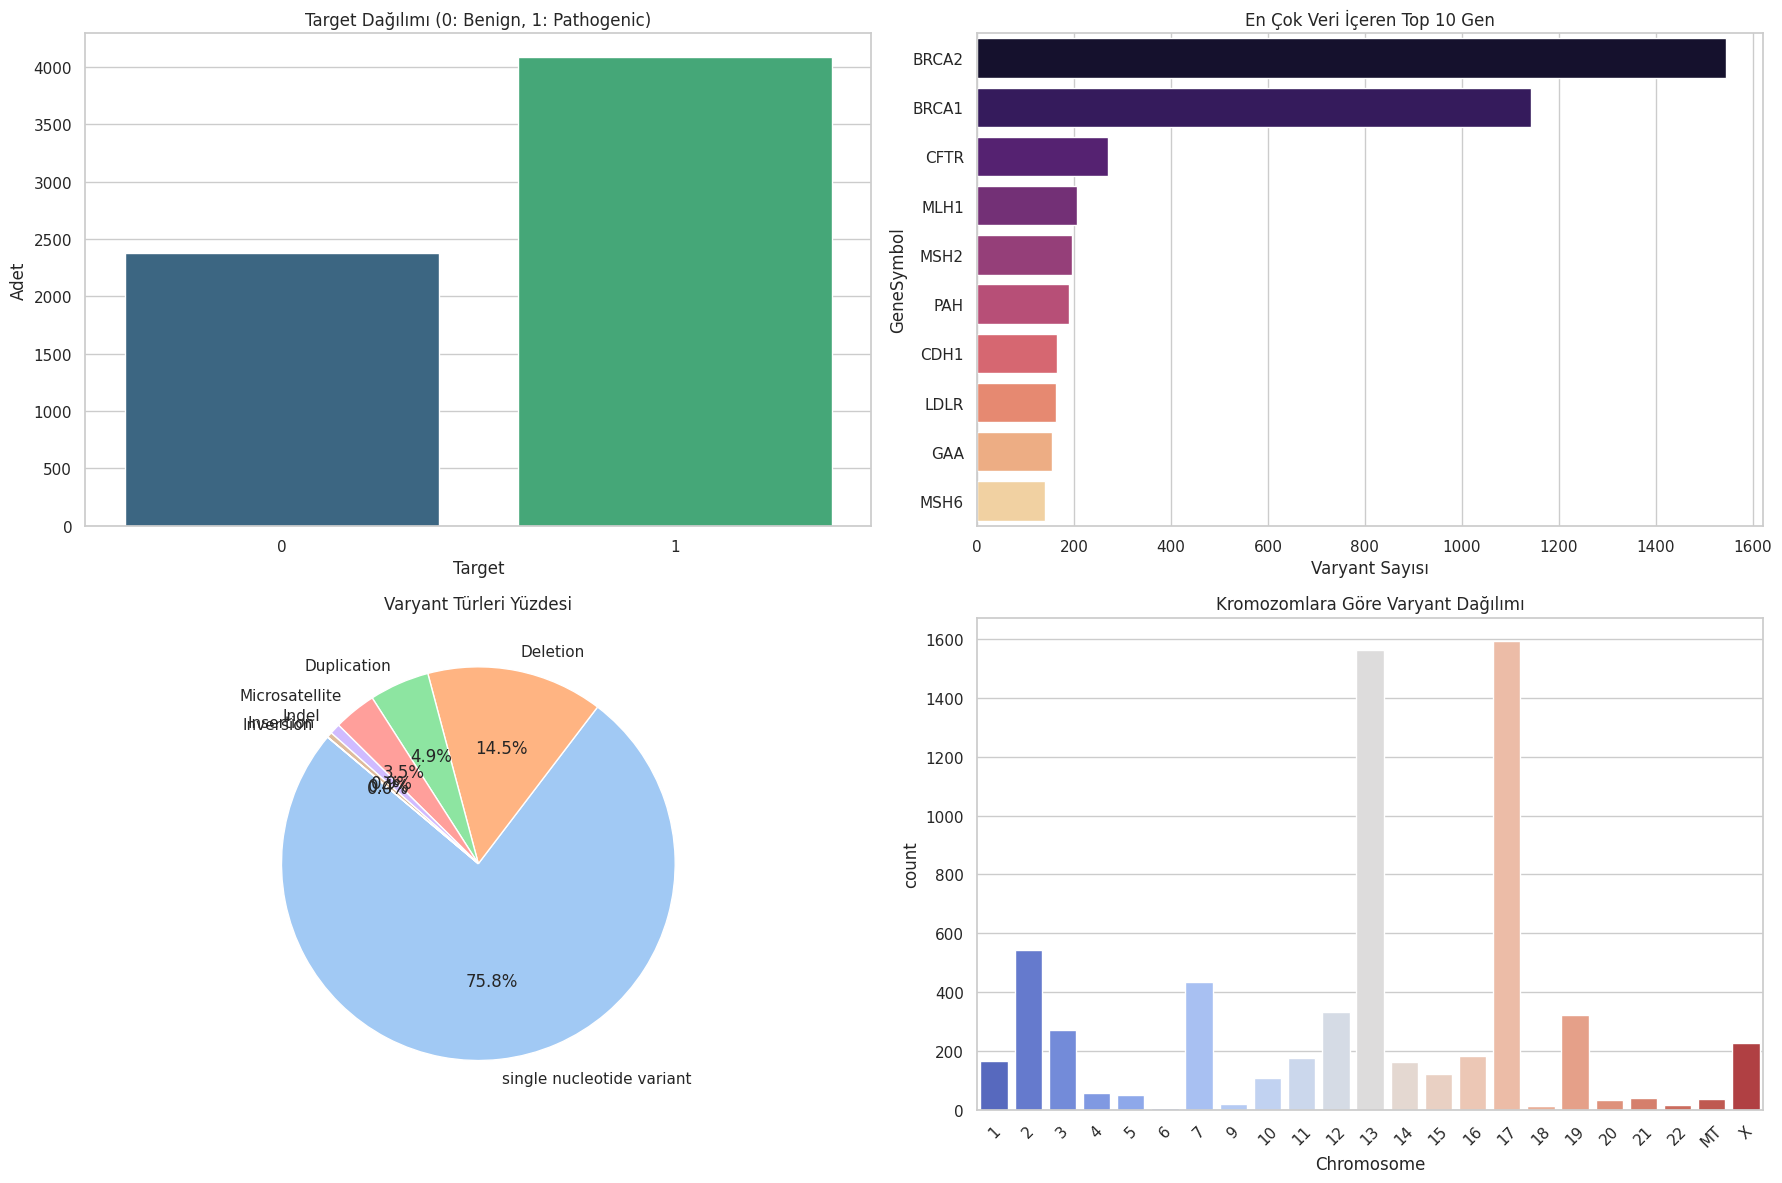

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükle
df = pd.read_csv('gold_standard_v3.csv')

# Görselleştirme stilini ayarla
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# 1. Target Dağılımı (Sınıf Dengesi)
plt.subplot(2, 2, 1)
sns.countplot(x='Target', data=df, palette='viridis')
plt.title('Target Dağılımı (0: Benign, 1: Pathogenic)')
plt.ylabel('Adet')

# 2. En Sık Görülen 10 Gen
plt.subplot(2, 2, 2)
top_10_genes = df['GeneSymbol'].value_counts().nlargest(10)
sns.barplot(x=top_10_genes.values, y=top_10_genes.index, palette='magma')
plt.title('En Çok Veri İçeren Top 10 Gen')
plt.xlabel('Varyant Sayısı')

# 3. Varyant Türlerinin Dağılımı (Type)
plt.subplot(2, 2, 3)
type_counts = df['Type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Varyant Türleri Yüzdesi')

# 4. Kromozom Başına Varyant Sayısı
plt.subplot(2, 2, 4)
# Kromozomları sayısal sıralamak için (X, Y varsa ona göre düzenlenir)
df['Chromosome'] = df['Chromosome'].astype(str)
chrom_order = sorted(df['Chromosome'].unique(), key=lambda x: int(x) if x.isdigit() else 100)
sns.countplot(x='Chromosome', data=df, order=chrom_order, palette='coolwarm')
plt.title('Kromozomlara Göre Varyant Dağılımı')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
!pip install xgboost==1.6.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.9/192.9 MB 6.2 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


🚀 Model eğitiliyor (Ezber kontrolü aktif)...


/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:793: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(



✅ EĞİTİM TAMAMLANDI
Doğruluk Skoru: %75.89

--- Karmaşıklık Matrisi ---
[[415  61]
 [251 567]]

--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.62      0.87      0.73       476
           1       0.90      0.69      0.78       818

    accuracy                           0.76      1294
   macro avg       0.76      0.78      0.76      1294
weighted avg       0.80      0.76      0.76      1294



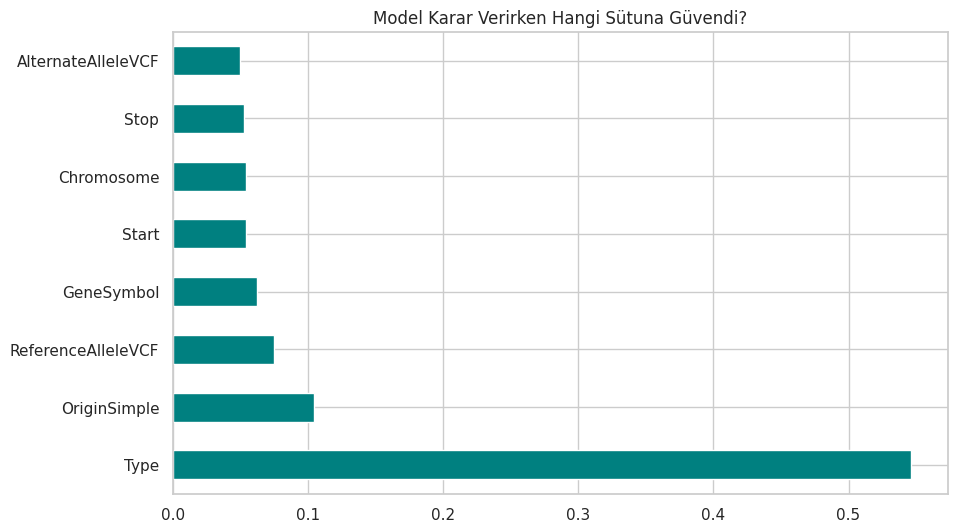

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Yükle
df = pd.read_csv('gold_standard_v3.csv')

# 2. Gereksiz ve Sızıntı Yapabilecek Sütunları Ayıkla
# Target ile aynı bilgiyi taşıyan veya kimlik belirten sütunları çıkarıyoruz
cols_to_drop = ['ClinSigSimple', 'PositionVCF', 'NumberSubmitters', 'Origin']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3. Kategorik Verileri İşleme (Encoding)
# 'Type' ve 'OriginSimple' gibi az seçenekli veriler için Label Encoding uygundur.
le = LabelEncoder()
for col in ['Type', 'OriginSimple', 'Chromosome', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']:
    df[col] = le.fit_transform(df[col].astype(str))

# 'GeneSymbol' için: Ezberlemeyi önlemek adına frekans bazlı bir yaklaşım veya Label Encoding
df['GeneSymbol'] = le.fit_transform(df['GeneSymbol'].astype(str))

# 4. Eğitim ve Test Ayrımı (Stratified: Sınıf oranlarını korur)
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. XGBoost Model Yapılandırması (Ezber Önleyici Parametreler)
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,               # Ağaç derinliğini düşük tutarak ezberi (overfitting) engelliyoruz
    learning_rate=0.01,        # Yavaş öğrenme, daha sağlam genelleme sağlar
    subsample=0.8,             # Her adımda verinin sadece %80'ini kullan (rastlantısallık)
    colsample_bytree=0.8,      # Her adımda sütunların sadece %80'ini kullan
    gamma=1,                   # Dallanma için minimum kayıp azaltımı (budama yapar)
    scale_pos_weight=len(y[y==0])/len(y[y==1]), # Sınıf dengesizliğini giderir
    use_label_encoder=False,
    eval_metric='logloss'
)

# 6. Eğitim
print("🚀 Model eğitiliyor (Ezber kontrolü aktif)...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=50,  # Test hatası artmaya başladığı an eğitimi durdurur (En iyi ezber önleyici)
    verbose=False
)

# 7. Sonuçlar
y_pred = model.predict(X_test)
print("\n✅ EĞİTİM TAMAMLANDI")
print(f"Doğruluk Skoru: %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\n--- Karmaşıklık Matrisi ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

# 8. Özellik Önemi (Hangi sütun ne kadar etkili?)
plt.figure(figsize=(10,6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Model Karar Verirken Hangi Sütuna Güvendi?')
plt.show()

In [ ]:
!pip install --upgrade scikit-learn xgboost

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Veriyi Hazırla (Aynı temizlik adımları)
df = pd.read_csv('gold_standard_v3.csv')
cols_to_drop = ['ClinSigSimple', 'PositionVCF', 'NumberSubmitters', 'Origin', 'Oncogenicity_Score']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

le = LabelEncoder()
for col in ['Type', 'GeneSymbol', 'OriginSimple', 'Chromosome', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop('Target', axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Denenecek Parametre Havuzu (Grid)
param_grid = {
    'max_depth': [4, 6, 8],           # Ağaçların derinliğini biraz artırıyoruz
    'learning_rate': [0.01, 0.05, 0.1], # Öğrenme hızlarını çeşitlendiriyoruz
    'n_estimators': [200, 500],       # Ağaç sayısını optimize ediyoruz
    'subsample': [0.8, 0.9]           # Veri örnekleme oranını hassaslaştırıyoruz
}

# 3. Arama İşlemini Başlat
print("🔎 En iyi parametreler aranıyor (Bu işlem birkaç dakika sürebilir)...")
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,             # 3 katlı çapraz doğrulama
    scoring='accuracy',
    verbose=1,
    n_jobs=-1         # İşlemci çekirdeklerinin tamamını kullan
)

grid_search.fit(X_train, y_train)

# 4. En İyi Modeli Al ve Test Et
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n🏆 EN İYİ PARAMETRELER BULUNDU:")
print(grid_search.best_params_)

print(f"\n🚀 Yeni Doğruluk Skoru: %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\n--- Yeni Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

🔎 En iyi parametreler aranıyor (Bu işlem birkaç dakika sürebilir)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

🏆 EN İYİ PARAMETRELER BULUNDU:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

🚀 Yeni Doğruluk Skoru: %79.44

--- Yeni Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.75      0.66      0.70       476
           1       0.82      0.87      0.84       818

    accuracy                           0.79      1294
   macro avg       0.78      0.77      0.77      1294
weighted avg       0.79      0.79      0.79      1294



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


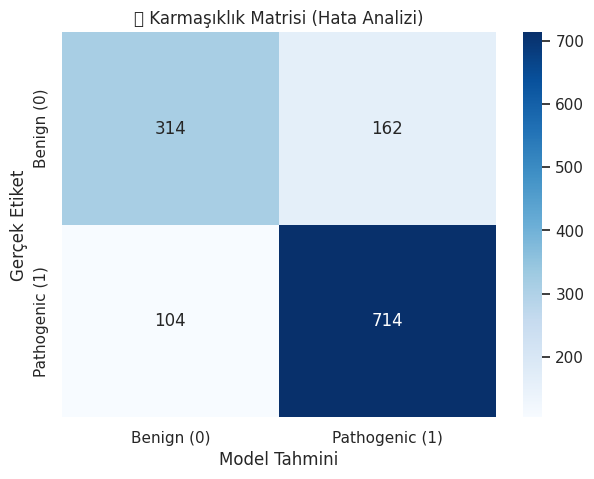

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


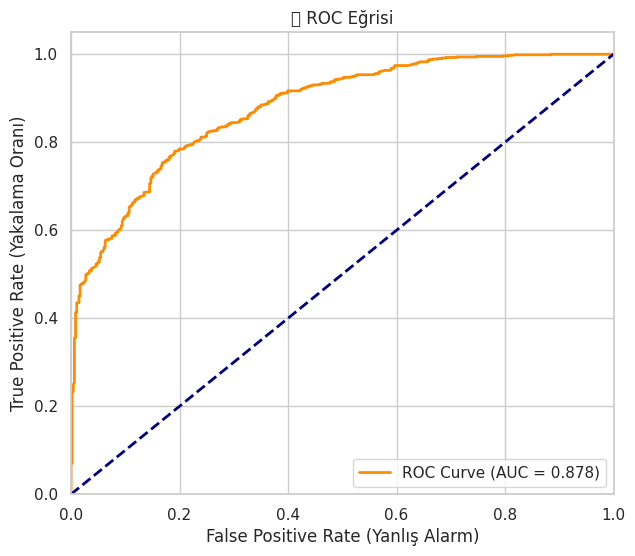

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


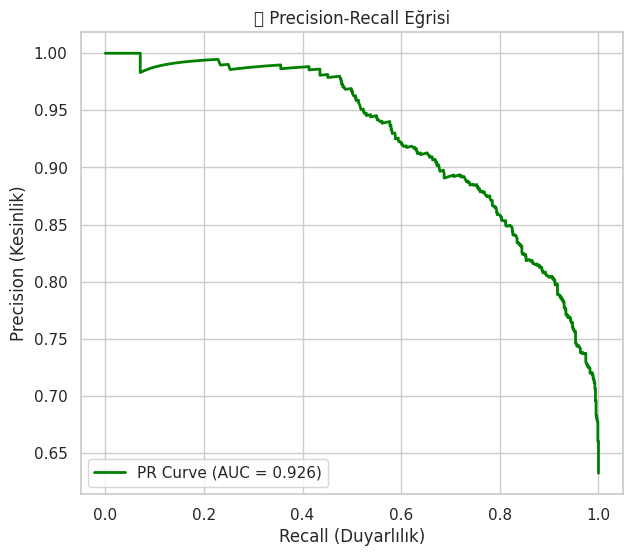

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


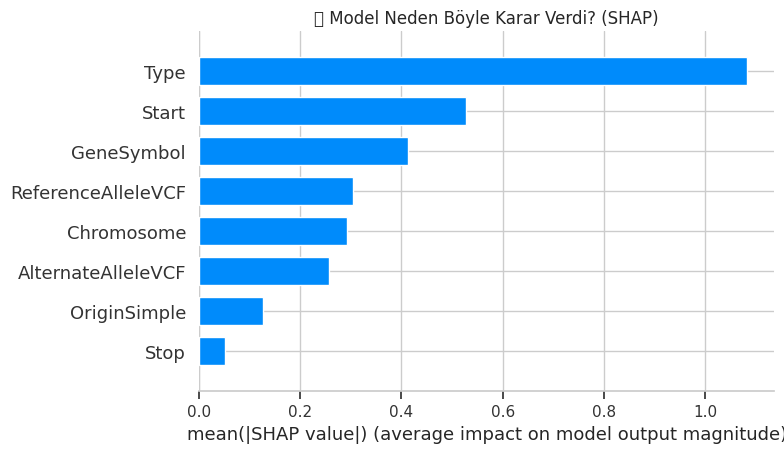

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# Grafiklerin genel stil ayarı
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 8]

# 1. Karmaşıklık Matrisi (4.3 Hata Analizi İçin)
def plot_confusion_matrix(model, X, y):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)', 'Pathogenic (1)'],
                yticklabels=['Benign (0)', 'Pathogenic (1)'])
    plt.title('🎯 Karmaşıklık Matrisi (Hata Analizi)')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Model Tahmini')
    plt.show()

# 2. ROC Eğrisi (4.2 Performans Metrikleri İçin)
def plot_roc_curve(model, X, y):
    y_probs = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Yanlış Alarm)')
    plt.ylabel('True Positive Rate (Yakalama Oranı)')
    plt.title('📈 ROC Eğrisi')
    plt.legend(loc="lower right")
    plt.show()

# 3. Precision-Recall Eğrisi (4.2 Panel Bazlı Raporlama İçin)
def plot_pr_curve(model, X, y):
    y_probs = model.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_probs)
    pr_auc = average_precision_score(y, y_probs)

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, color='green', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall (Duyarlılık)')
    plt.ylabel('Precision (Kesinlik)')
    plt.title('📊 Precision-Recall Eğrisi')
    plt.legend(loc="lower left")
    plt.show()

# 4. SHAP Analizi (4.4 Açıklanabilirlik İçin)
# Not: Önce '!pip install shap' komutuyla yüklemeniz gerekebilir.
import shap

def plot_shap_summary(model, X):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    plt.title('🧬 Model Neden Böyle Karar Verdi? (SHAP)')
    shap.summary_plot(shap_values, X, plot_type="bar")

# --- GRAFİKLERİ ÇALIŞTIR ---
plot_confusion_matrix(best_model, X_test, y_test)
plot_roc_curve(best_model, X_test, y_test)
plot_pr_curve(best_model, X_test, y_test)
plot_shap_summary(best_model, X_test)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


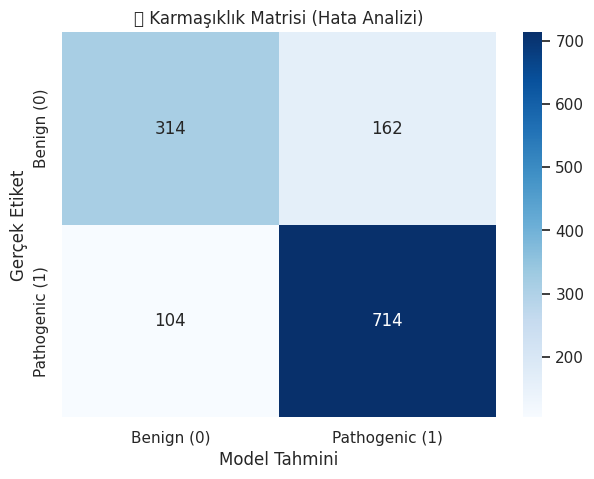

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


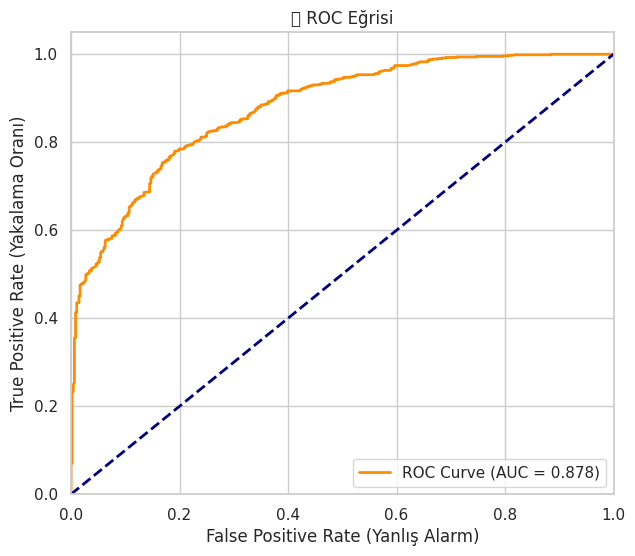

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


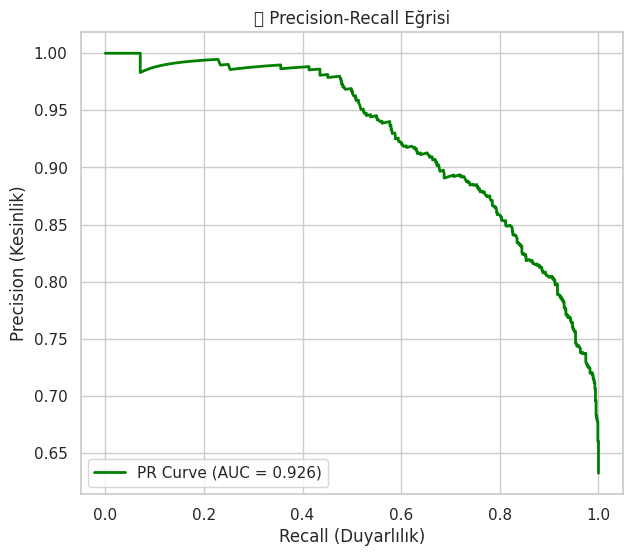

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


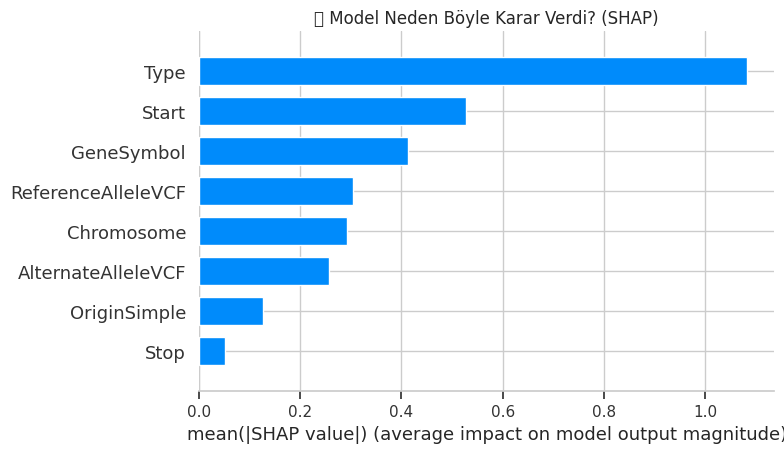

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# Grafiklerin genel stil ayarı
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 8]

# 1. Karmaşıklık Matrisi (4.3 Hata Analizi İçin)
def plot_confusion_matrix(model, X, y):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)', 'Pathogenic (1)'],
                yticklabels=['Benign (0)', 'Pathogenic (1)'])
    plt.title('🎯 Karmaşıklık Matrisi (Hata Analizi)')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Model Tahmini')
    plt.show()

# 2. ROC Eğrisi (4.2 Performans Metrikleri İçin)
def plot_roc_curve(model, X, y):
    y_probs = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Yanlış Alarm)')
    plt.ylabel('True Positive Rate (Yakalama Oranı)')
    plt.title('📈 ROC Eğrisi')
    plt.legend(loc="lower right")
    plt.show()

# 3. Precision-Recall Eğrisi (4.2 Panel Bazlı Raporlama İçin)
def plot_pr_curve(model, X, y):
    y_probs = model.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_probs)
    pr_auc = average_precision_score(y, y_probs)

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, color='green', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall (Duyarlılık)')
    plt.ylabel('Precision (Kesinlik)')
    plt.title('📊 Precision-Recall Eğrisi')
    plt.legend(loc="lower left")
    plt.show()

# 4. SHAP Analizi (4.4 Açıklanabilirlik İçin)
# Not: Önce '!pip install shap' komutuyla yüklemeniz gerekebilir.
import shap

def plot_shap_summary(model, X):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    plt.title('🧬 Model Neden Böyle Karar Verdi? (SHAP)')
    shap.summary_plot(shap_values, X, plot_type="bar")

# --- GRAFİKLERİ ÇALIŞTIR ---
plot_confusion_matrix(best_model, X_test, y_test)
plot_roc_curve(best_model, X_test, y_test)
plot_pr_curve(best_model, X_test, y_test)
plot_shap_summary(best_model, X_test)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


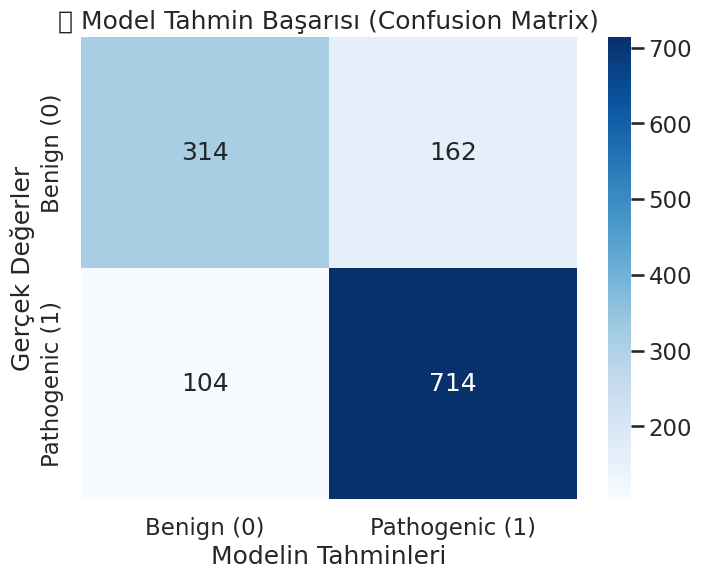

📌 Özet Analiz:
- Doğru Benign Tahmini: 314
- Doğru Pathogenic Tahmini: 714
- Iskaladığımız Patojenler (Kritik Hata): 104


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def gorsel_karmasiklik_matrisi(y_gercek, y_tahmin):
    # 1. Matrisi Hesapla
    cm = confusion_matrix(y_gercek, y_tahmin)

    # 2. Görselleştirme Ayarları
    plt.figure(figsize=(8, 6))
    sns.set_context("talk") # Yazıların daha okunaklı olması için

    # Isı haritasını çiz
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)', 'Pathogenic (1)'],
                yticklabels=['Benign (0)', 'Pathogenic (1)'])

    plt.title('🎯 Model Tahmin Başarısı (Confusion Matrix)')
    plt.ylabel('Gerçek Değerler')
    plt.xlabel('Modelin Tahminleri')

    # 3. Grafik Altı Analiz Notu
    plt.show()

    # Hızlı Özet Yazdır
    dogru_0 = cm[0,0]
    yanlis_0 = cm[0,1]
    dogru_1 = cm[1,1]
    yanlis_1 = cm[1,0]

    print(f"📌 Özet Analiz:")
    print(f"- Doğru Benign Tahmini: {dogru_0}")
    print(f"- Doğru Pathogenic Tahmini: {dogru_1}")
    print(f"- Iskaladığımız Patojenler (Kritik Hata): {yanlis_1}")

# Kullanımı (GridSearch sonrası):
y_pred = best_model.predict(X_test)
gorsel_karmasiklik_matrisi(y_test, y_pred)

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder




# 1. Veriyi Hazırla (Aynı temizlik adımları)
df = pd.read_csv('gold_standard_v3.csv')


cols_to_drop = ['ClinSigSimple', 'PositionVCF', 'NumberSubmitters', 'Origin', 'Oncogenicity_Score']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

le = LabelEncoder()
for col in ['Type', 'GeneSymbol', 'OriginSimple', 'Chromosome', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop('Target', axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Denenecek Parametre Havuzu (Grid)
param_grid = {
    'max_depth': [4, 6, 8],           # Ağaçların derinliğini biraz artırıyoruz
    'learning_rate': [0.01, 0.05, 0.1], # Öğrenme hızlarını çeşitlendiriyoruz
    'n_estimators': [200, 500],       # Ağaç sayısını optimize ediyoruz
    'subsample': [0.8, 0.9]           # Veri örnekleme oranını hassaslaştırıyoruz
}

# 3. Arama İşlemini Başlat
print("🔎 En iyi parametreler aranıyor (Bu işlem birkaç dakika sürebilir)...")
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,             # 3 katlı çapraz doğrulama
    scoring='accuracy',
    verbose=1,
    n_jobs=-1         # İşlemci çekirdeklerinin tamamını kullan
)

grid_search.fit(X_train, y_train)

# 4. En İyi Modeli Al ve Test Et
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n🏆 EN İYİ PARAMETRELER BULUNDU:")
print(grid_search.best_params_)

print(f"\n🚀 Yeni Doğruluk Skoru: %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\n--- Yeni Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

🔎 En iyi parametreler aranıyor (Bu işlem birkaç dakika sürebilir)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

🏆 EN İYİ PARAMETRELER BULUNDU:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

🚀 Yeni Doğruluk Skoru: %79.44

--- Yeni Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.75      0.66      0.70       476
           1       0.82      0.87      0.84       818

    accuracy                           0.79      1294
   macro avg       0.78      0.77      0.77      1294
weighted avg       0.79      0.79      0.79      1294



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


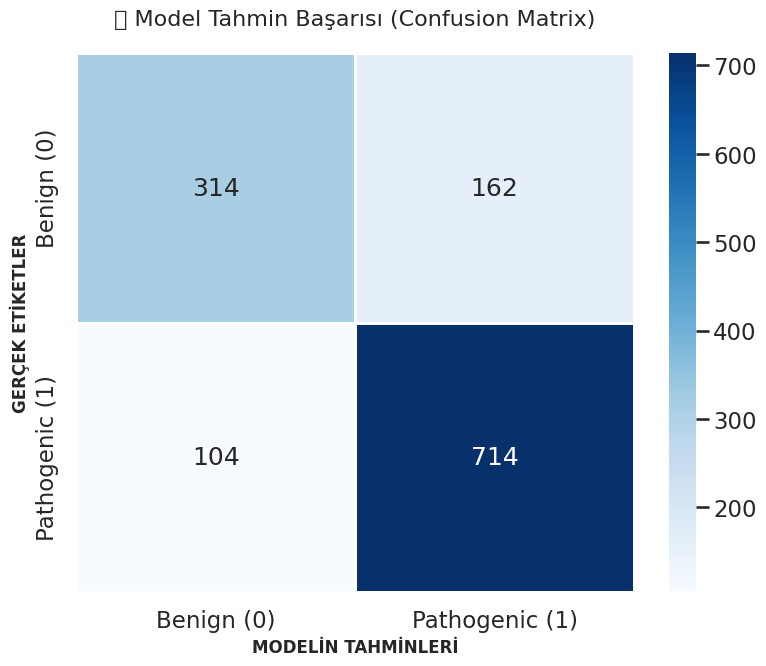

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def gorsel_karmasiklik_matrisi_ciz(model, X_test, y_test):
    """
    Eğitilmiş bir modelin test verisi üzerindeki karmaşıklık matrisini
    görsel bir ısı haritası (heatmap) olarak çizer.
    """
    # 1. Modelden tahminleri al
    y_pred = model.predict(X_test)

    # 2. Sayısal Karmaşıklık Matrisini Hesapla
    cm = confusion_matrix(y_test, y_pred)

    # 3. Görselleştirme Ayarları
    plt.figure(figsize=(9, 7))
    sns.set_context("talk") # Yazıların okunaklı olması için boyutu ayarlar

    # Isı haritasını (heatmap) oluştur
    # cmap='Blues' mavi tonları kullanır, annot=True sayıları içine yazar
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                linewidths=2, linecolor='white', # Hücreler arasına beyaz çizgi ekler
                xticklabels=['Benign (0)', 'Pathogenic (1)'],
                yticklabels=['Benign (0)', 'Pathogenic (1)'])

    # Eksen etiketleri ve başlık
    plt.title('🎯 Model Tahmin Başarısı (Confusion Matrix)', fontsize=16, pad=20)
    plt.ylabel('GERÇEK ETİKETLER', fontsize=12, fontweight='bold')
    plt.xlabel('MODELİN TAHMİNLERİ', fontsize=12, fontweight='bold')

    plt.show()

# --- KULLANIMI ---
# GridSearchCV'den dönen 'best_model' değişkenini kullanıyoruz
# X_test ve y_test ise senin ayırdığın test verileri
gorsel_karmasiklik_matrisi_ciz(best_model, X_test, y_test)

In [ ]:
import joblib
import pandas as pd

# 1. Modeli geri yükle
yuklenen_model = joblib.load('kanser_varyant_modeli_v1.pkl')

# 2. TEST: Elimizdeki test setinden rastgele 5 satır alalım (yeni veri taklidi yapalım)
yeni_veri_ornegi = X_test.iloc[:5]

# 3. Tahmin yap
tahminler = yuklenen_model.predict(yeni_veri_ornegi)
olasiliklar = yuklenen_model.predict_proba(yeni_veri_ornegi) # Ne kadar emin olduğunu gösterir

# 4. Sonuçları yazdır
print("🚀 Modelin Yeni Veriler Üzerindeki Tahminleri:")
for i, tahmin in enumerate(tahminler):
    durum = "Pathogenic (1)" if tahmin == 1 else "Benign (0)"
    eminlik = olasiliklar[i][tahmin] * 100
    print(f"Varyant {i+1}: Tahmin -> {durum} | Güven Oranı: %{eminlik:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'kanser_varyant_modeli_v1.pkl'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# Grafiklerin genel stil ayarı
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 8]

# 1. Karmaşıklık Matrisi (4.3 Hata Analizi İçin)
def plot_confusion_matrix(model, X, y):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)', 'Pathogenic (1)'],
                yticklabels=['Benign (0)', 'Pathogenic (1)'])
    plt.title('🎯 Karmaşıklık Matrisi (Hata Analizi)')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Model Tahmini')
    plt.show()

# 2. ROC Eğrisi (4.2 Performans Metrikleri İçin)
def plot_roc_curve(model, X, y):
    y_probs = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Yanlış Alarm)')
    plt.ylabel('True Positive Rate (Yakalama Oranı)')
    plt.title('📈 ROC Eğrisi')
    plt.legend(loc="lower right")
    plt.show()

# 3. Precision-Recall Eğrisi (4.2 Panel Bazlı Raporlama İçin)
def plot_pr_curve(model, X, y):
    y_probs = model.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_probs)
    pr_auc = average_precision_score(y, y_probs)

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, color='green', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall (Duyarlılık)')
    plt.ylabel('Precision (Kesinlik)')
    plt.title('📊 Precision-Recall Eğrisi')
    plt.legend(loc="lower left")
    plt.show()

# 4. SHAP Analizi (4.4 Açıklanabilirlik İçin)
# Not: Önce '!pip install shap' komutuyla yüklemeniz gerekebilir.
import shap

def plot_shap_summary(model, X):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    plt.title('🧬 Model Neden Böyle Karar Verdi? (SHAP)')
    shap.summary_plot(shap_values, X, plot_type="bar")

# --- GRAFİKLERİ ÇALIŞTIR ---
plot_confusion_matrix(best_model, X_test, y_test)
plot_roc_curve(best_model, X_test, y_test)
plot_pr_curve(best_model, X_test, y_test)
plot_shap_summary(best_model, X_test)